## Phase 2 — Funnel Analysis

Goal: Track user behaviour across 6 months of billing/payment data.
Dataset: credit_users (30,000 users)

Funnel stages:
1. All users
2. Users who were billed (active card users)
3. Users who made at least one payment
4. Users who paid consistently (3+ months)
5. Users who never defaulted (loyal users)

graph TD
    A[All Users: 30,000] --> B[Active Users]
    B --> C[Paying Users]
    C --> D[Consistent Payers: 3+ Months]
    D --> E[Loyal Users: Zero Defaults]

In [33]:
# Libraries
import pandas as pd
from sqlalchemy import create_engine
import sqlite3
import matplotlib.pyplot as plt


In [2]:
# Connect to SQLite database
engine = create_engine("sqlite:///../db/cc_intelligence.db")

## Dataset 2 — Default rate by credit limit bucket

In [3]:
df_credit = pd.read_csv("../data/UCI_Credit_Card.csv")
df_credit.columns = df_credit.columns.str.lower().str.strip()
df_credit.to_sql("credit_users", engine, if_exists="replace", index=False)
print(f"Loaded {len(df_credit):,} rows into 'credit_users'")

Loaded 30,000 rows into 'credit_users'


In [5]:
con = sqlite3.connect("../db/cc_intelligence.db")
print(pd.read_sql("SELECT * FROM credit_users LIMIT 3", con))

   id  limit_bal  sex  education  marriage  age  pay_0  pay_2  pay_3  pay_4  \
0   1    20000.0    2          2         1   24      2      2     -1     -1   
1   2   120000.0    2          2         2   26     -1      2      0      0   
2   3    90000.0    2          2         2   34      0      0      0      0   

   ...  bill_amt4  bill_amt5  bill_amt6  pay_amt1  pay_amt2  pay_amt3  \
0  ...        0.0        0.0        0.0       0.0     689.0       0.0   
1  ...     3272.0     3455.0     3261.0       0.0    1000.0    1000.0   
2  ...    14331.0    14948.0    15549.0    1518.0    1500.0    1000.0   

   pay_amt4  pay_amt5  pay_amt6  default.payment.next.month  
0       0.0       0.0       0.0                           1  
1    1000.0       0.0    2000.0                           1  
2    1000.0    1000.0    5000.0                           0  

[3 rows x 25 columns]


In [6]:
%reload_ext sql

In [7]:
%load_ext sql
%sql sqlite:///../db/cc_intelligence.db

The sql extension is already loaded. To reload it, use:
  %reload_ext sql


In [8]:
%config SqlMagic.style = '_DEPRECATED_DEFAULT'

In [9]:
%config SqlMagic.style = 'PLAIN_COLUMNS'

In [11]:
%%sql
PRAGMA table_info(credit_users);

 * sqlite:///../db/cc_intelligence.db
Done.


cid,name,type,notnull,dflt_value,pk
0,id,BIGINT,0,None,0
1,limit_bal,FLOAT,0,None,0
2,sex,BIGINT,0,None,0
3,education,BIGINT,0,None,0
4,marriage,BIGINT,0,None,0
5,age,BIGINT,0,None,0
6,pay_0,BIGINT,0,None,0
7,pay_2,BIGINT,0,None,0
8,pay_3,BIGINT,0,None,0
9,pay_4,BIGINT,0,None,0


In [12]:
%%sql
SELECT * FROM credit_users
LIMIT 5;

 * sqlite:///../db/cc_intelligence.db
Done.


id,limit_bal,sex,education,marriage,age,pay_0,pay_2,pay_3,pay_4,pay_5,pay_6,bill_amt1,bill_amt2,bill_amt3,bill_amt4,bill_amt5,bill_amt6,pay_amt1,pay_amt2,pay_amt3,pay_amt4,pay_amt5,pay_amt6,default.payment.next.month
1,20000.0,2,2,1,24,2,2,-1,-1,-2,-2,3913.0,3102.0,689.0,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
2,120000.0,2,2,2,26,-1,2,0,0,0,2,2682.0,1725.0,2682.0,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
3,90000.0,2,2,2,34,0,0,0,0,0,0,29239.0,14027.0,13559.0,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
4,50000.0,2,2,1,37,0,0,0,0,0,0,46990.0,48233.0,49291.0,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
5,50000.0,1,2,1,57,-1,0,-1,0,0,0,8617.0,5670.0,35835.0,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


### Total users

In [13]:
%%sql
SELECT COUNT(*) AS total_users
FROM credit_users;

 * sqlite:///../db/cc_intelligence.db
Done.


total_users
30000


### Users who were actually billed

In [14]:
%%sql
SELECT COUNT(*) AS billed_users
FROM credit_users
WHERE bill_amt1 > 0
   OR bill_amt2 > 0
   OR bill_amt3 > 0
   OR bill_amt4 > 0
   OR bill_amt5 > 0
   OR bill_amt6 > 0;

 * sqlite:///../db/cc_intelligence.db
Done.


billed_users
29034


### Users who made at least one payment

In [15]:
%%sql
SELECT COUNT(*) AS paid_atleast_once
FROM credit_users
WHERE pay_amt1 > 0
   OR pay_amt2 > 0
   OR pay_amt3 > 0
   OR pay_amt4 > 0
   OR pay_amt5 > 0
   OR pay_amt6 > 0;

 * sqlite:///../db/cc_intelligence.db
Done.


paid_atleast_once
28568


### Users who paid consistently (3 or more months)

In [16]:
%%sql
SELECT COUNT(*) AS consistent_payers
FROM credit_users
WHERE (
    (CASE WHEN pay_amt1 > 0 THEN 1 ELSE 0 END) +
    (CASE WHEN pay_amt2 > 0 THEN 1 ELSE 0 END) +
    (CASE WHEN pay_amt3 > 0 THEN 1 ELSE 0 END) +
    (CASE WHEN pay_amt4 > 0 THEN 1 ELSE 0 END) +
    (CASE WHEN pay_amt5 > 0 THEN 1 ELSE 0 END) +
    (CASE WHEN pay_amt6 > 0 THEN 1 ELSE 0 END)
) >= 3;

 * sqlite:///../db/cc_intelligence.db
Done.


consistent_payers
26262


In [25]:
%%sql
SELECT COUNT(*) AS loyal_users
FROM credit_users
WHERE "default.payment.next.month" = 0;

 * sqlite:///../db/cc_intelligence.db
Done.


loyal_users
23364


In [30]:
%%sql
SELECT 
    "default.payment.next.month" AS default_flag,
    COUNT(*) AS users,
    ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (), 2) AS pct
FROM credit_users
GROUP BY default_flag;

 * sqlite:///../db/cc_intelligence.db
Done.


default_flag,users,pct
0,23364,77.88
1,6636,22.12


### Funnel summary table

In [31]:
funnel = pd.DataFrame([
    {'stage': '1. All users',         'users': 30000},
    {'stage': '2. Billed users',       'users': 29034},
    {'stage': '3. Paid at least once', 'users': 28568},
    {'stage': '4. Consistent payers',  'users': 26262},
    {'stage': '5. Loyal users',        'users': 23364},
])

funnel['drop_from_prev'] = funnel['users'].shift(1) - funnel['users']
funnel['drop_pct'] = (funnel['drop_from_prev'] / funnel['users'].shift(1) * 100).round(2)

print(funnel)

                   stage  users  drop_from_prev  drop_pct
0           1. All users  30000             NaN       NaN
1        2. Billed users  29034           966.0      3.22
2  3. Paid at least once  28568           466.0      1.61
3   4. Consistent payers  26262          2306.0      8.07
4         5. Loyal users  23364          2898.0     11.03


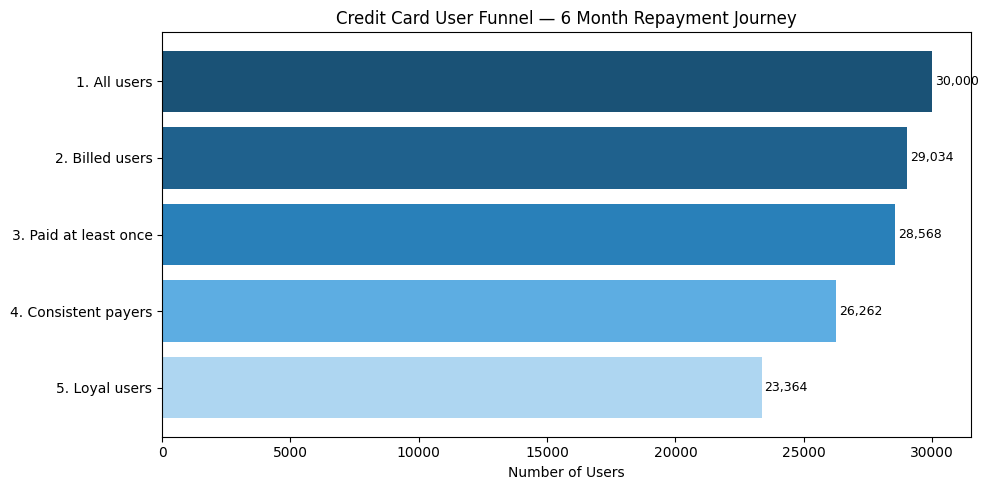

In [ ]:

colors = ['#1a5276', '#1f618d', '#2980b9', '#5dade2', '#aed6f1']

plt.figure(figsize=(10, 5))
plt.barh(funnel['stage'], funnel['users'], color=colors)
plt.xlabel('Number of Users')
plt.title('Credit Card User Funnel — 6 Month Repayment Journey')
plt.gca().invert_yaxis()
for i, row in funnel.iterrows():
    plt.text(row['users'] + 100, i, f"{row['users']:,}", va='center', fontsize=9)
plt.tight_layout()
plt.show()

## Phase 2 — Funnel Findings

| Stage | Users | Drop-off |
|---|---|---|
| All users | 30,000 | — |
| Billed users | 29,034 | 3.2% |
| Paid at least once | 28,568 | 1.6% |
| Consistent payers | 26,262 | 8.1% |
| Loyal users | 23,364 | 11.0% |

**Key findings:**

1. **Activation is strong** — 96.8% of users got billed, meaning almost 
   everyone actively used their card.

2. **Biggest drop is at consistency** — 8.1% of paying users couldn't 
   sustain payments across 3+ months. This is your highest-risk segment 
   to target with early intervention.

3. **1 in 5 users defaulted** — 22.1% of all users (6,636 people) failed 
   to make it to the loyal stage. This is the business cost.

4. **Funnel efficiency = 77.9%** — meaning if you onboard 100 users, 
   roughly 78 will be loyal long-term. 